# Notebook 02 — Exploratory Analysis
## Rappi Delivery Operations Dataset

**Purpose:** Pattern discovery and relationship analysis using the cleaned dataset.

**Inputs:**
- `outputs/cleaned/raw_data_clean.parquet`
- `outputs/cleaned/zone_info_clean.parquet`

**Outputs:**
- `outputs/figures/` — distribution, time, correlation, and geographic charts
- `outputs/tables/eda_summary_*.csv` — summary tables

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import seaborn as sns

from src.config import TABLES_DIR
from src.io_utils import load_cleaned, save_csv
from src.plotting import (
    plot_distribution, plot_hourly_profile, plot_correlation_matrix,
    plot_ranked_bar, save_fig,
)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print("Libraries loaded.")

raw       = load_cleaned("raw_data_clean")
zone_info = load_cleaned("zone_info_clean")
print(f"RAW_DATA: {raw.shape[0]:,} rows × {raw.shape[1]} cols")
print(f"Date range: {raw['DATE'].min().date()} → {raw['DATE'].max().date()}")
print(f"Cities: {raw['CITY'].nunique()}  |  Zones: {raw['ZONE'].nunique()}")

Libraries loaded.
RAW_DATA: 10,080 rows × 17 cols
Date range: 2024-03-01 → 2024-03-30
Cities: 1  |  Zones: 14


---
## A. Univariate Analysis

### Categorical Variables


COUNTRY — 1 unique values:
COUNTRY
Mexico    10080

CITY — 1 unique values:
CITY
Monterrey    10080

ZONE — 14 unique values:
ZONE
Centro                 720
Mitras Centro          720
Apodaca Centro         720
Escobedo               720
Carretera Nacional     720
MTY_Apodaca_Huinalá    720
San Nicolás            720
Santa Catarina         720
San Pedro              720
Cumbres Poniente       720
La Fe                  720
MTY_Guadalupe          720
Independencia          720
Santiago               720
Figure saved → outputs\figures\eda_zone_row_counts.png


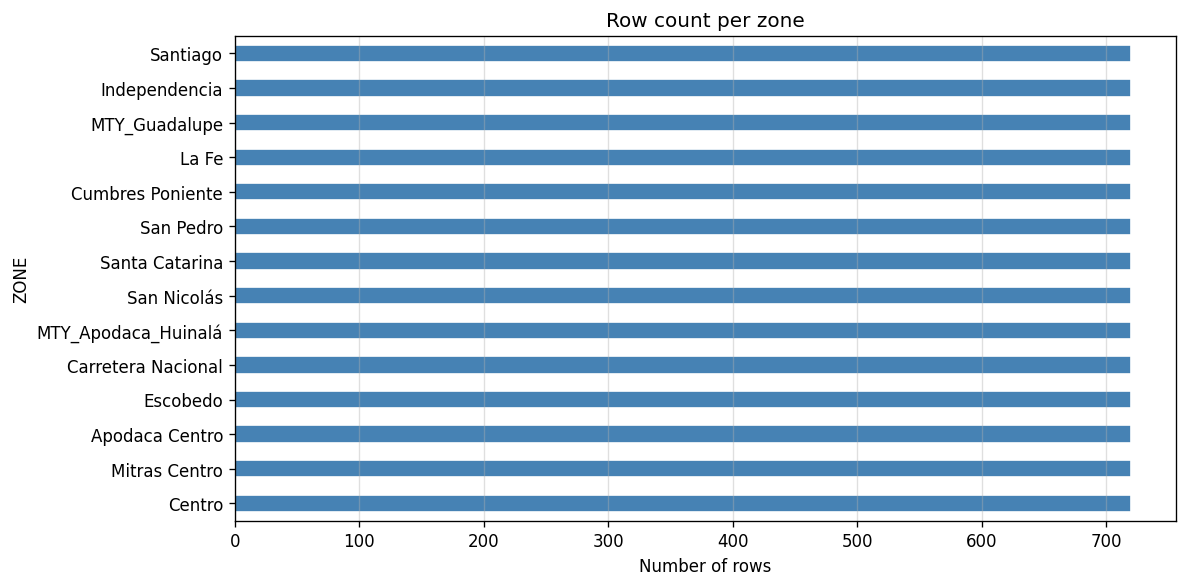

In [2]:
for col in ["COUNTRY", "CITY", "ZONE"]:
    if col in raw.columns:
        vc = raw[col].value_counts()
        print(f"\n{col} — {vc.shape[0]} unique values:")
        print(vc.to_string())

# Zone frequency bar chart
if "ZONE" in raw.columns:
    zone_counts = raw["ZONE"].value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(10, 5))
    zone_counts.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Row count per zone")
    ax.set_xlabel("Number of rows")
    ax.grid(axis="x", alpha=0.4)
    plt.tight_layout()
    save_fig(fig, "eda_zone_row_counts")
    plt.show()

### Numeric Variables

Summary statistics and distributions for the four core metrics.

Summary statistics:
                    count    mean     std   min   25%   50%   75%     95%   max  zero_rate
CONNECTED_RT      10080.0   9.143   7.650   1.0   3.0   7.0  13.0  25.000  46.0      0.000
ORDERS            10080.0   9.440  10.612   0.0   1.0   6.0  14.0  32.000  57.0      0.096
EARNINGS          10080.0  57.696   8.293  49.0  52.4  55.6  58.7  75.900  97.0      0.000
PRECIPITATION_MM  10080.0   0.247   1.265   0.0   0.0   0.0   0.0   0.405  10.3      0.939
Figure saved → outputs\figures\eda_dist_connected_rt.png


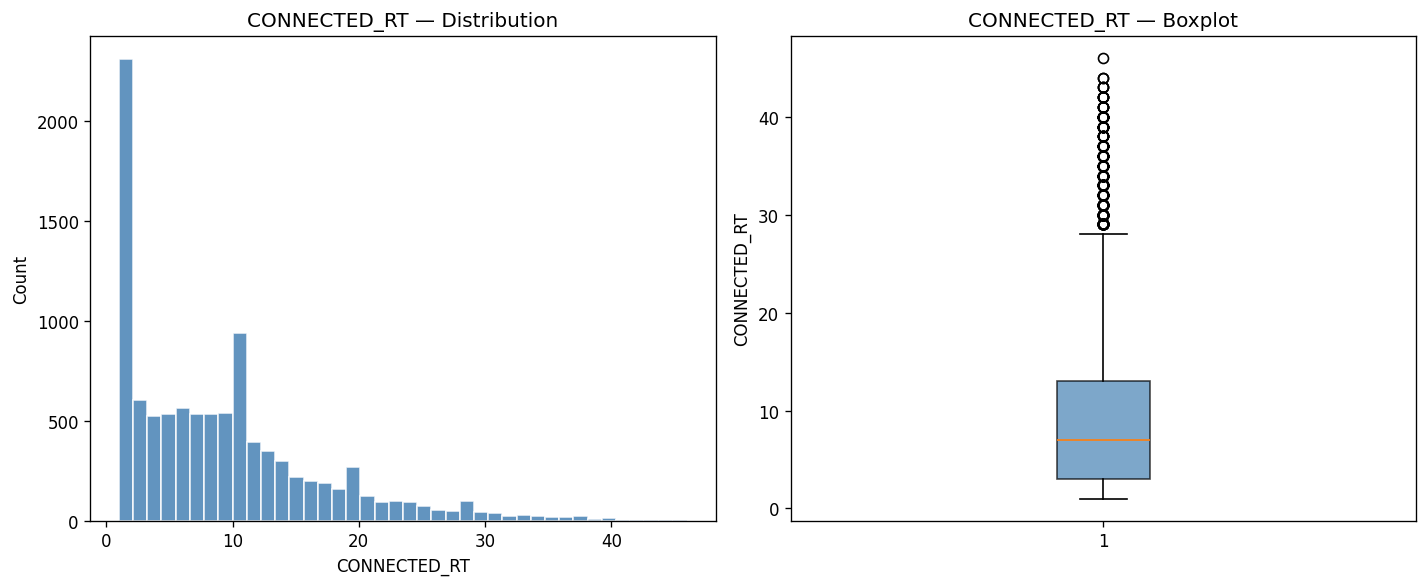

Figure saved → outputs\figures\eda_dist_orders.png


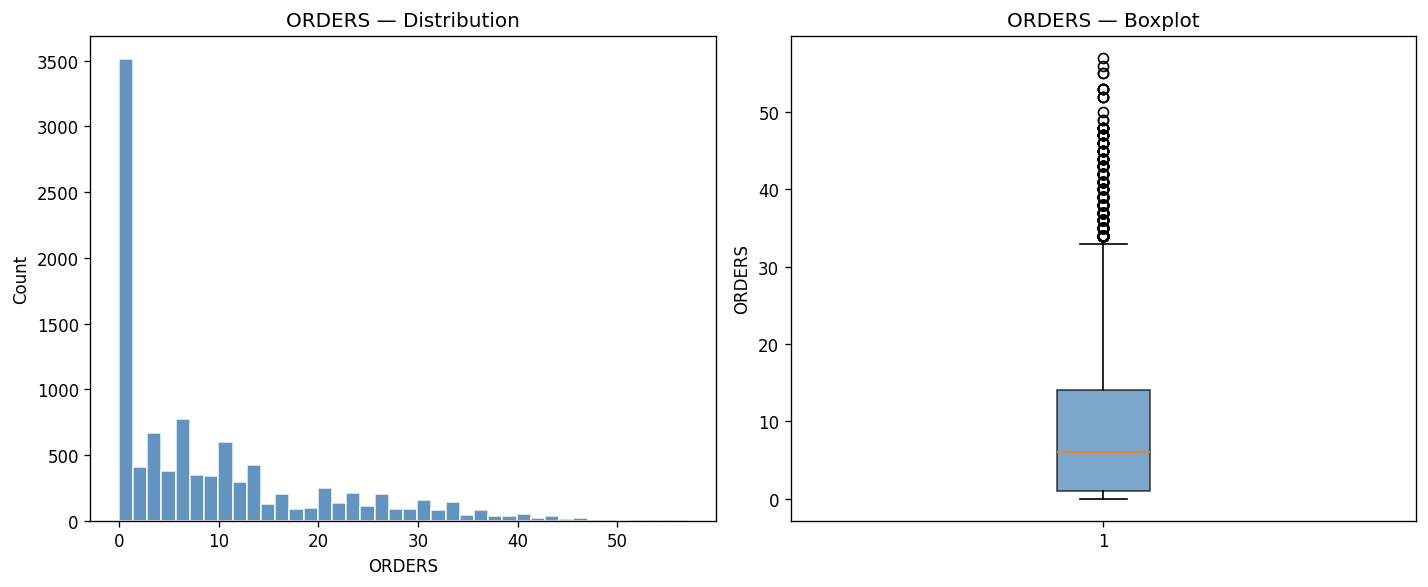

Figure saved → outputs\figures\eda_dist_earnings.png


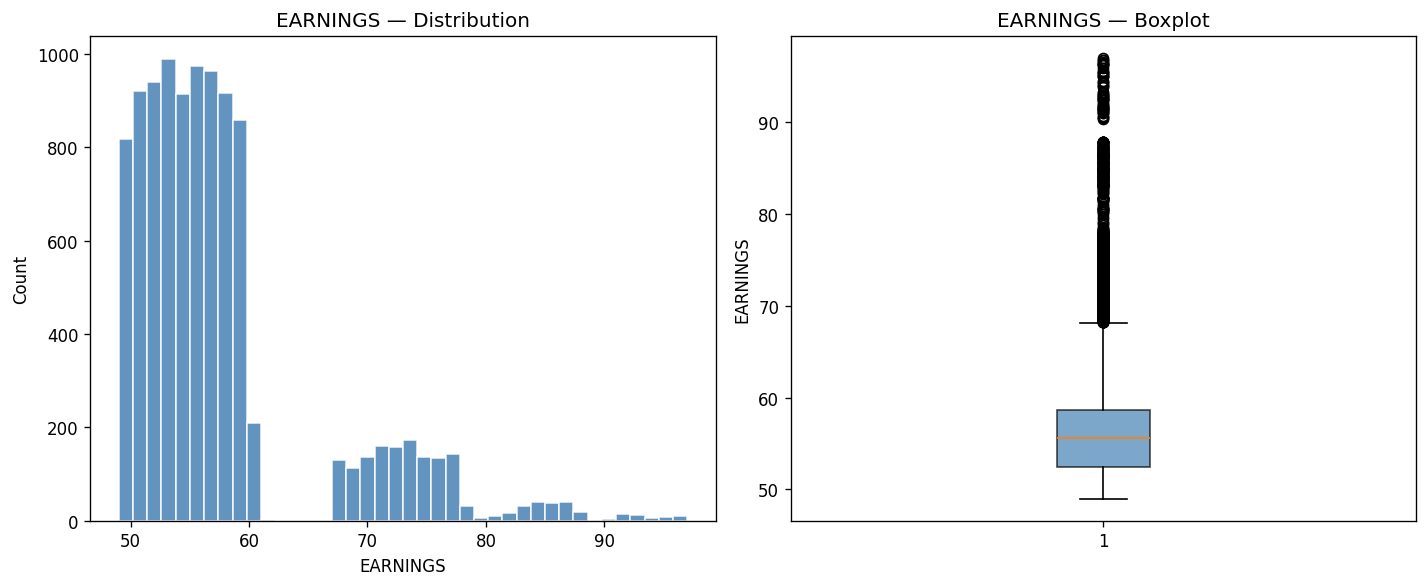

Figure saved → outputs\figures\eda_dist_precipitation_mm.png


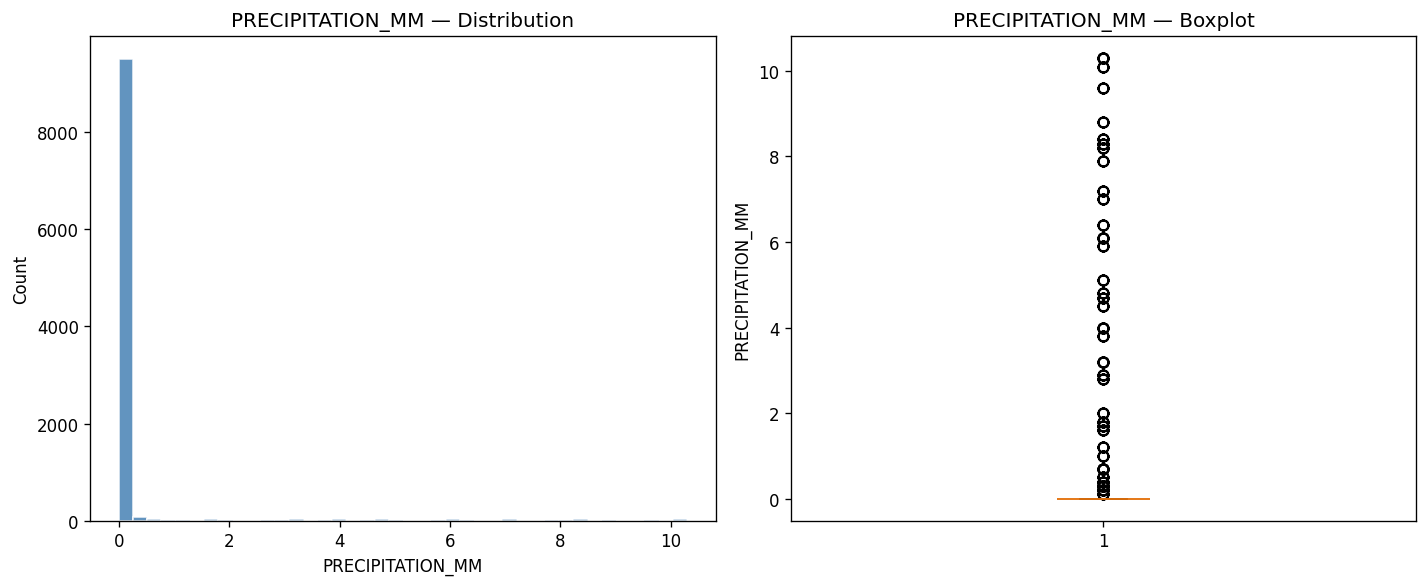

In [3]:
NUMERIC_COLS = ["CONNECTED_RT", "ORDERS", "EARNINGS", "PRECIPITATION_MM"]

# Summary statistics
stats = raw[NUMERIC_COLS].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T
stats["zero_rate"] = (raw[NUMERIC_COLS] == 0).mean().values
print("Summary statistics:")
print(stats.round(3).to_string())

# Distribution plots
for col in NUMERIC_COLS:
    fig = plot_distribution(raw[col], title=col)
    save_fig(fig, f"eda_dist_{col.lower()}")
    plt.show()

---
## B. Outlier Analysis

For each numeric metric: IQR thresholds, top extreme values, and suspicious combinations.

In [4]:
outlier_summary = []
for col in NUMERIC_COLS:
    s = raw[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_high = (s > upper).sum()
    n_low  = (s < lower).sum()
    outlier_summary.append({
        "Column": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "Lower_fence": lower, "Upper_fence": upper,
        "N_above_upper": n_high, "N_below_lower": n_low,
    })

outlier_df = pd.DataFrame(outlier_summary)
print("Outlier thresholds (IQR method):")
print(outlier_df.round(2).to_string(index=False))

# Suspicious combinations
suspicious = raw[
    (raw["EARNINGS"] > raw["EARNINGS"].quantile(0.9)) & (raw["ORDERS"] == 0)
]
print(f"\nHigh earnings with 0 orders: {len(suspicious)} rows")

overload = raw[
    (raw["ORDERS"] > raw["ORDERS"].quantile(0.95)) &
    (raw["CONNECTED_RT"] < raw["CONNECTED_RT"].quantile(0.1))
]
print(f"High orders with very low supply: {len(overload)} rows")

Outlier thresholds (IQR method):
          Column   Q1   Q3  IQR  Lower_fence  Upper_fence  N_above_upper  N_below_lower
    CONNECTED_RT  3.0 13.0 10.0       -12.00        28.00            297              0
          ORDERS  1.0 14.0 13.0       -18.50        33.50            422              0
        EARNINGS 52.4 58.7  6.3        42.95        68.15           1442              0
PRECIPITATION_MM  0.0  0.0  0.0         0.00         0.00            616              0

High earnings with 0 orders: 0 rows
High orders with very low supply: 0 rows


---
## C. Bivariate Relationships & Correlation

Examining pairwise relationships between core operational metrics and precipitation.

Figure saved → outputs\figures\eda_scatter_pairs.png


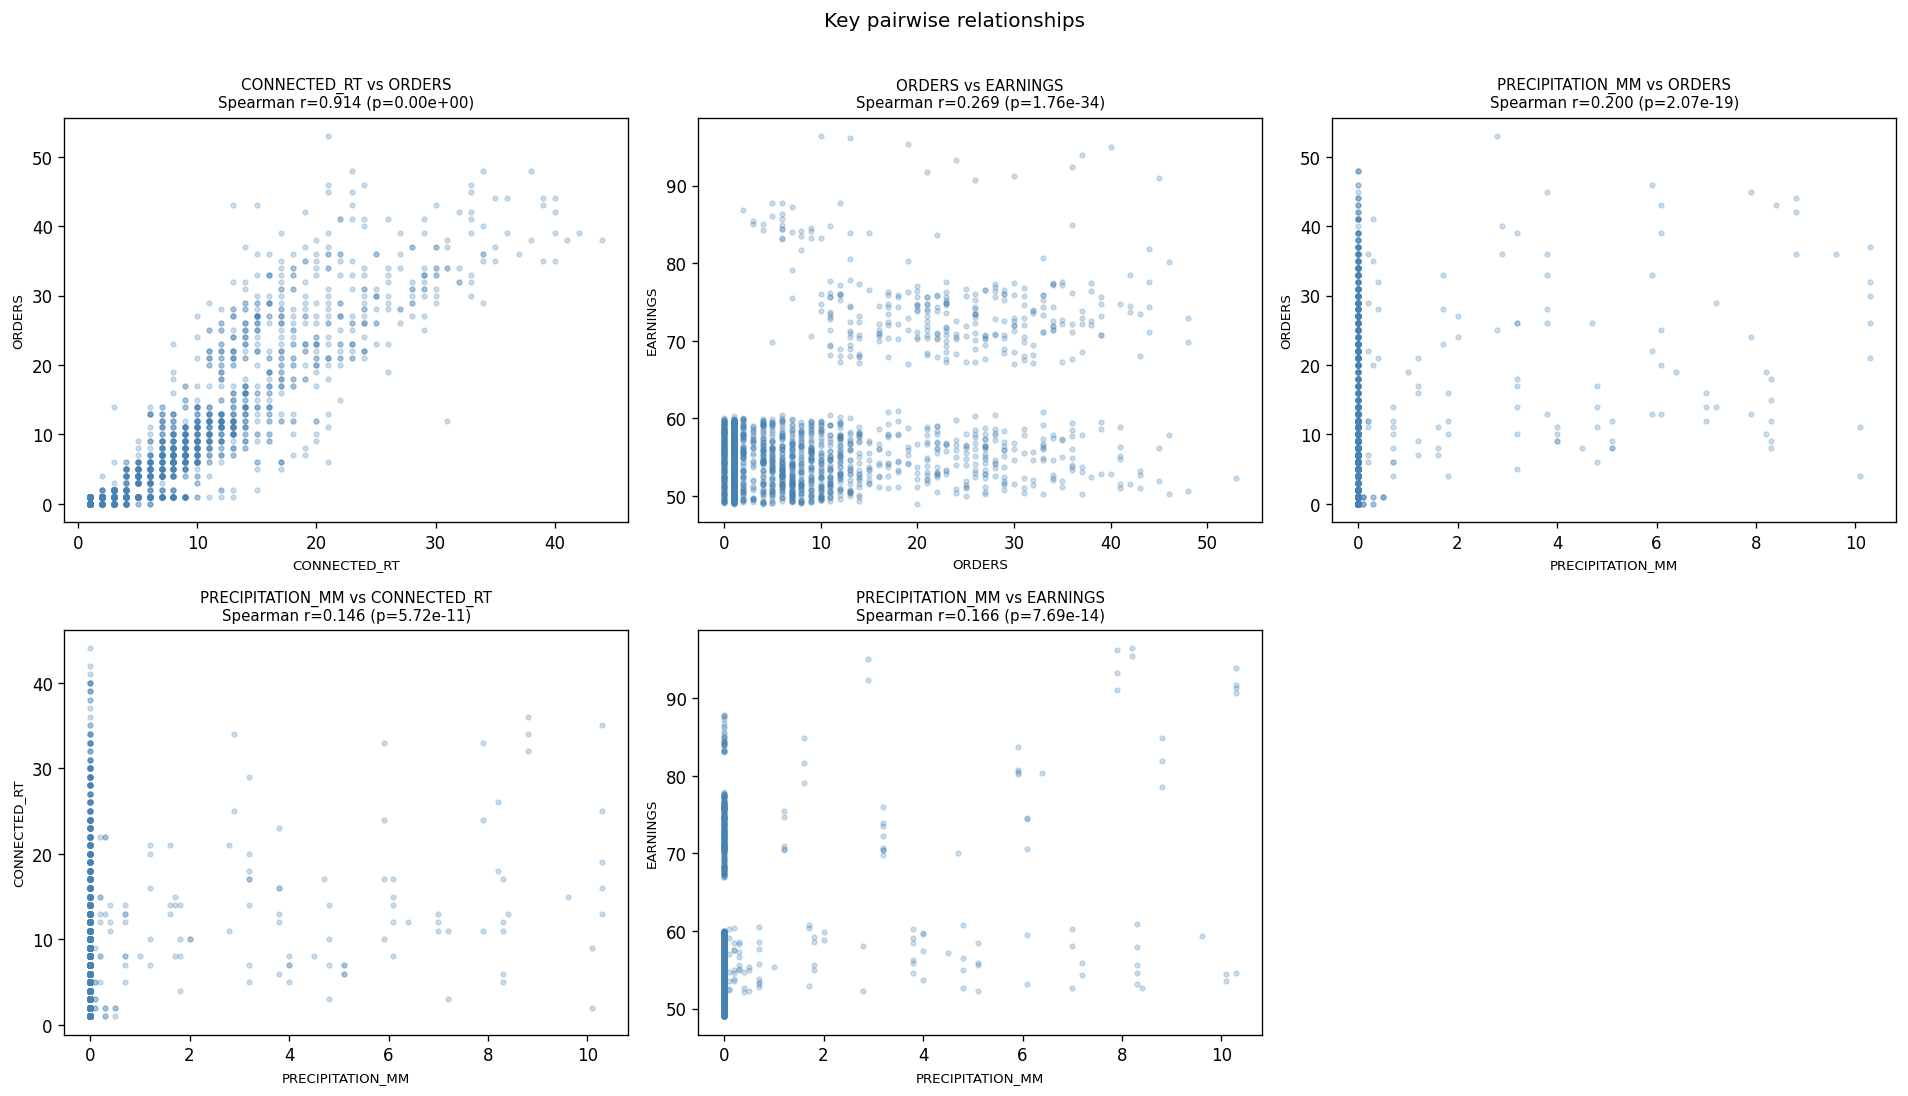

In [5]:
from scipy.stats import spearmanr

pairs = [
    ("CONNECTED_RT", "ORDERS"),
    ("ORDERS", "EARNINGS"),
    ("PRECIPITATION_MM", "ORDERS"),
    ("PRECIPITATION_MM", "CONNECTED_RT"),
    ("PRECIPITATION_MM", "EARNINGS"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(pairs):
    if x_col not in raw.columns or y_col not in raw.columns:
        continue
    sample = raw[[x_col, y_col]].dropna().sample(min(2000, len(raw)), random_state=42)
    axes[i].scatter(sample[x_col], sample[y_col], alpha=0.25, s=8, color="steelblue")
    r, p = spearmanr(sample[x_col], sample[y_col])
    axes[i].set_title(f"{x_col} vs {y_col}\nSpearman r={r:.3f} (p={p:.2e})", fontsize=9)
    axes[i].set_xlabel(x_col, fontsize=8)
    axes[i].set_ylabel(y_col, fontsize=8)

axes[-1].axis("off")
plt.suptitle("Key pairwise relationships", fontsize=12, y=1.01)
plt.tight_layout()
save_fig(fig, "eda_scatter_pairs")
plt.show()

Figure saved → outputs\figures\eda_corr_pearson.png


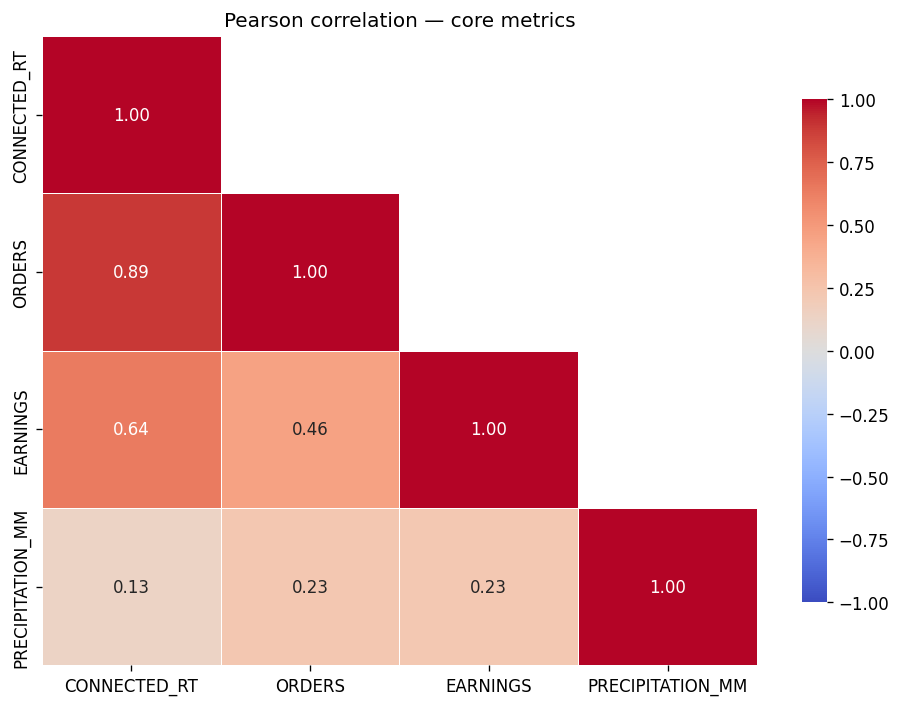

Figure saved → outputs\figures\eda_corr_spearman.png


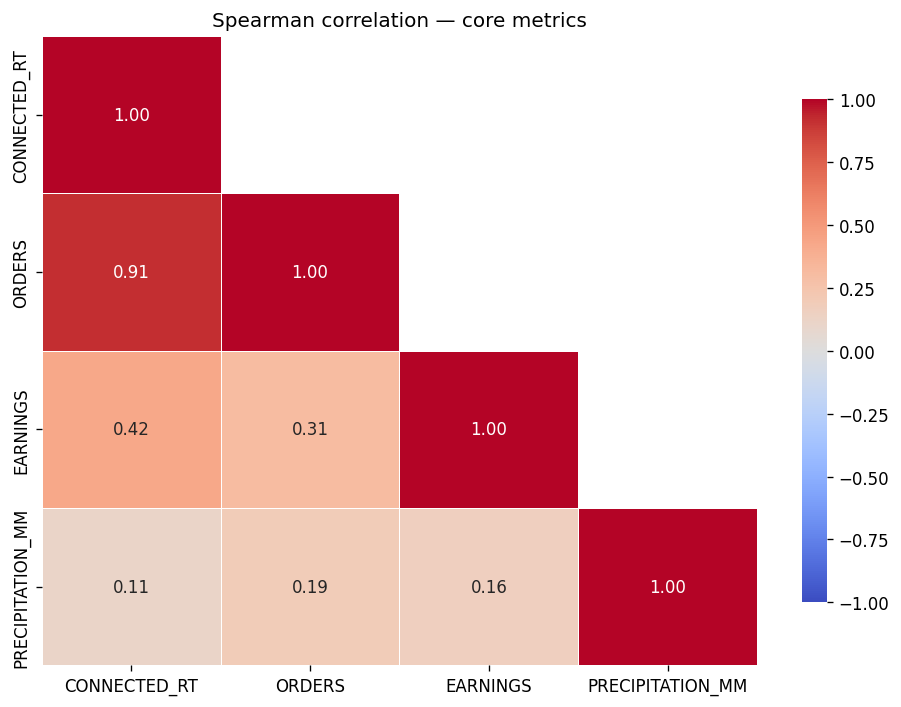

Note: correlation ≠ causation. Use as directional signal only.


In [6]:
# Pearson + Spearman correlation matrices
for method in ["pearson", "spearman"]:
    fig = plot_correlation_matrix(raw, method=method, cols=NUMERIC_COLS,
                                  title=f"{method.capitalize()} correlation — core metrics")
    save_fig(fig, f"eda_corr_{method}")
    plt.show()

print("Note: correlation ≠ causation. Use as directional signal only.")

---
## D. Time Analysis

Hourly profiles, daily trends, and weekday vs weekend comparisons.

Figure saved → outputs\figures\eda_hourly_connected_rt.png


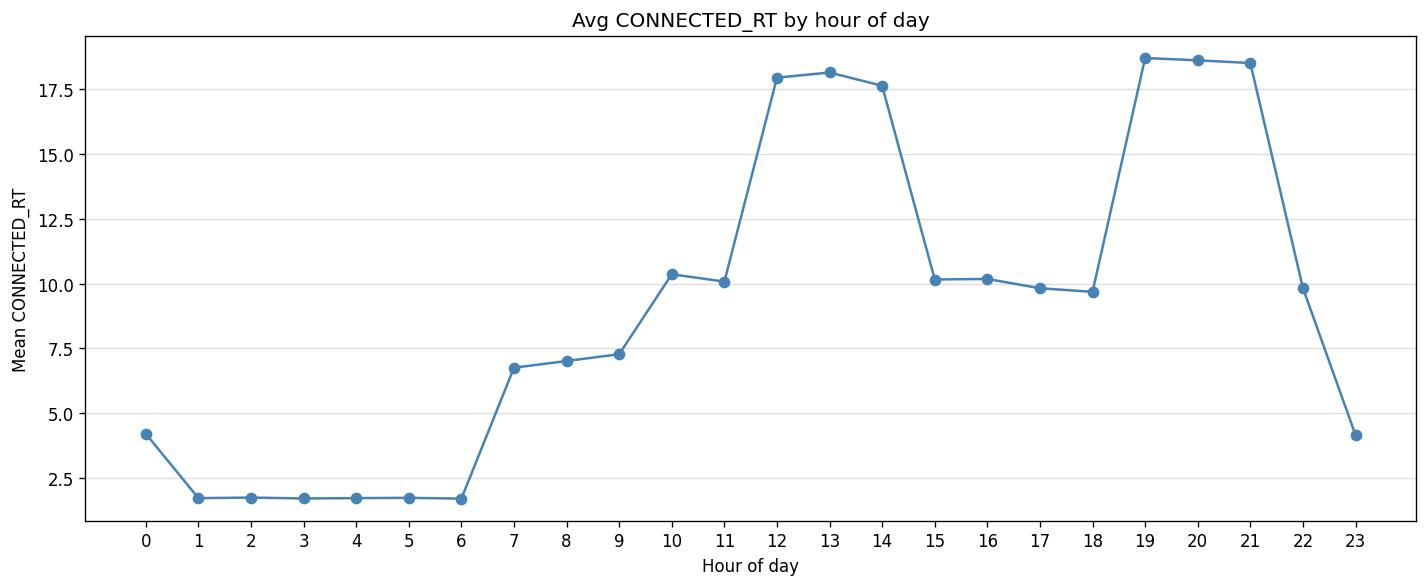

Figure saved → outputs\figures\eda_hourly_orders.png


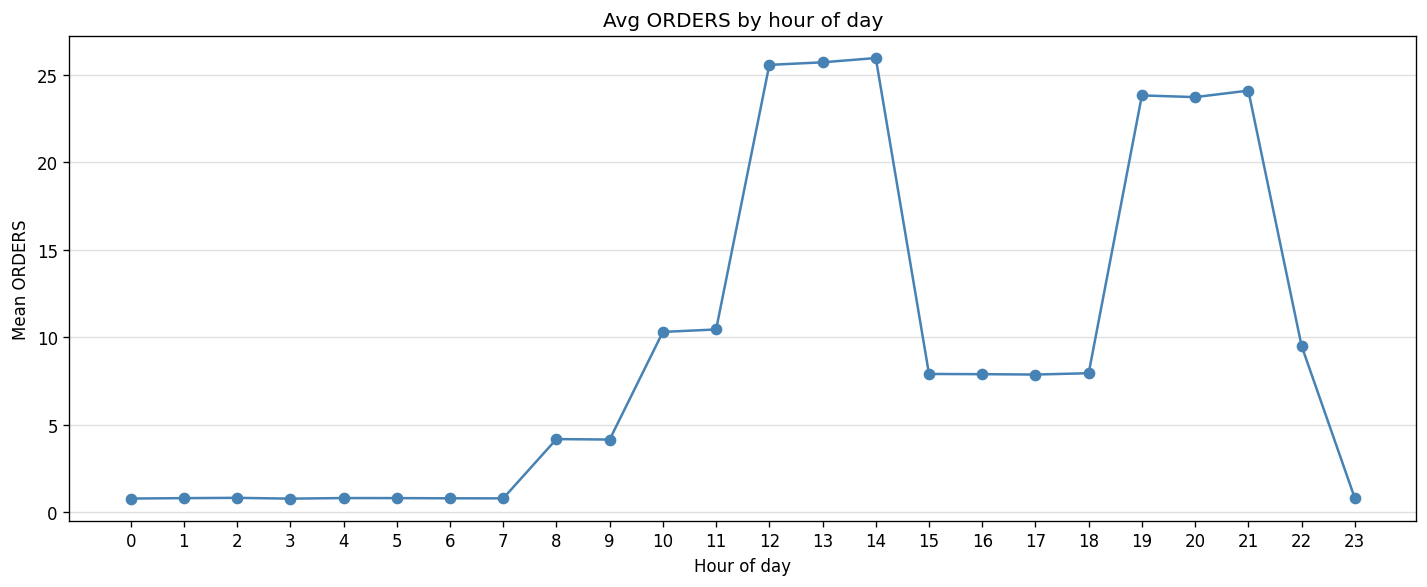

Figure saved → outputs\figures\eda_hourly_earnings.png


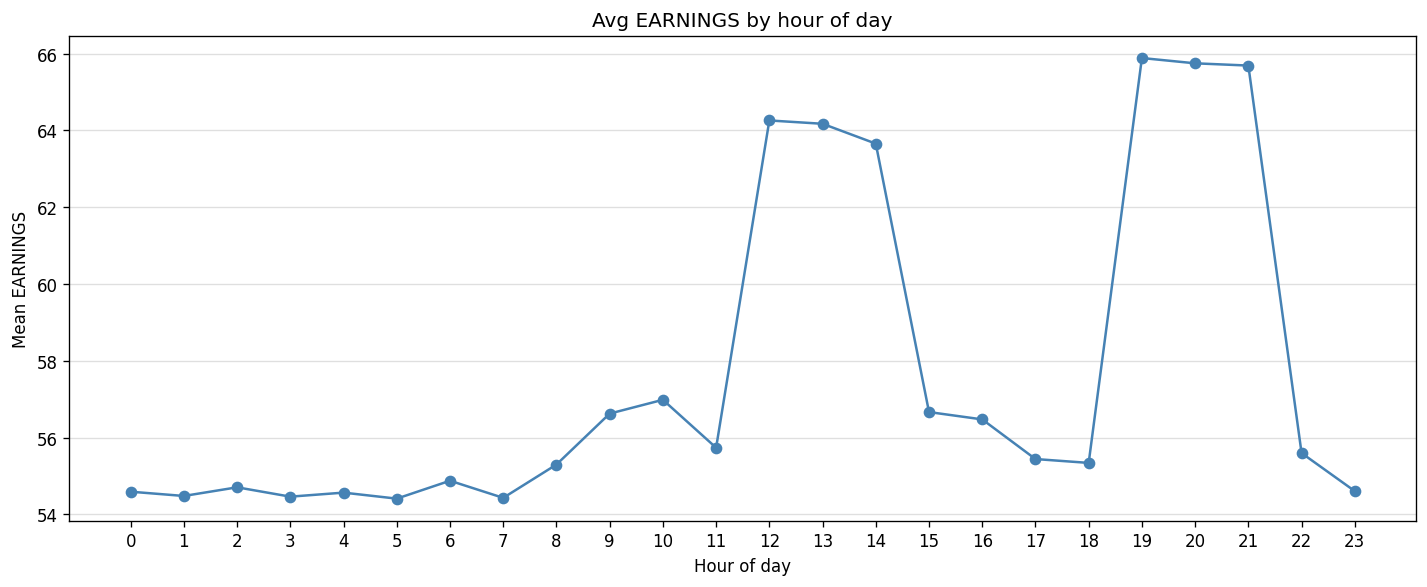

Figure saved → outputs\figures\eda_hourly_precipitation_mm.png


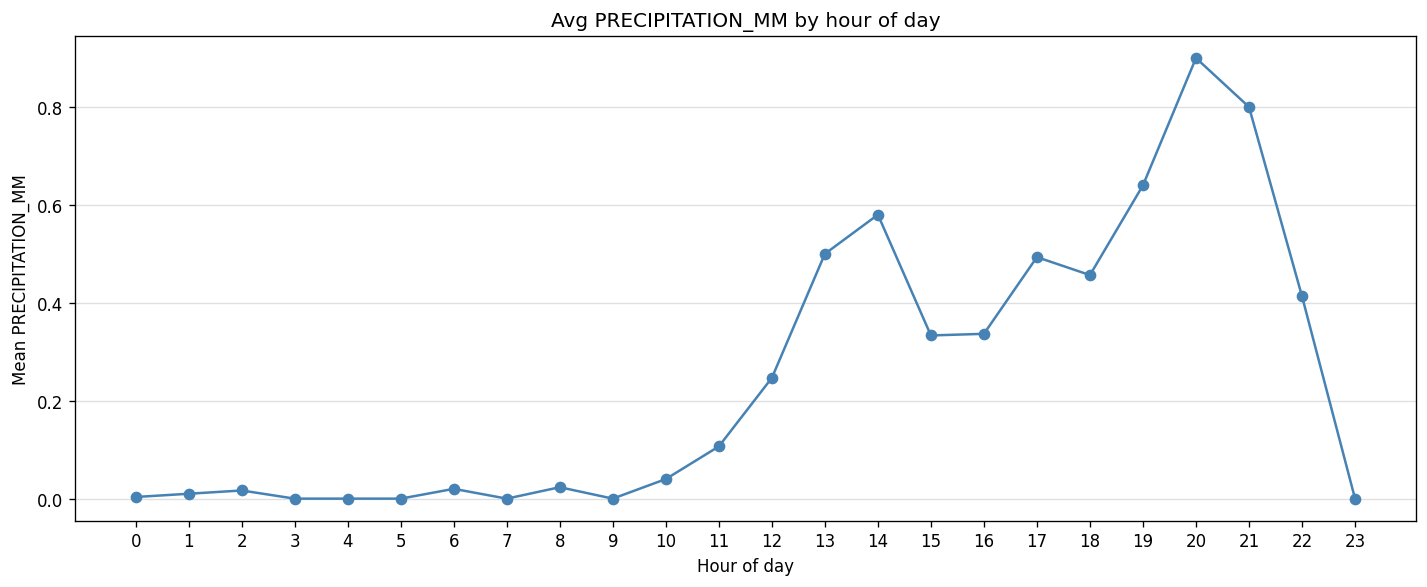

Figure saved → outputs\figures\eda_hourly_connected_rt_weekday_vs_weekend.png


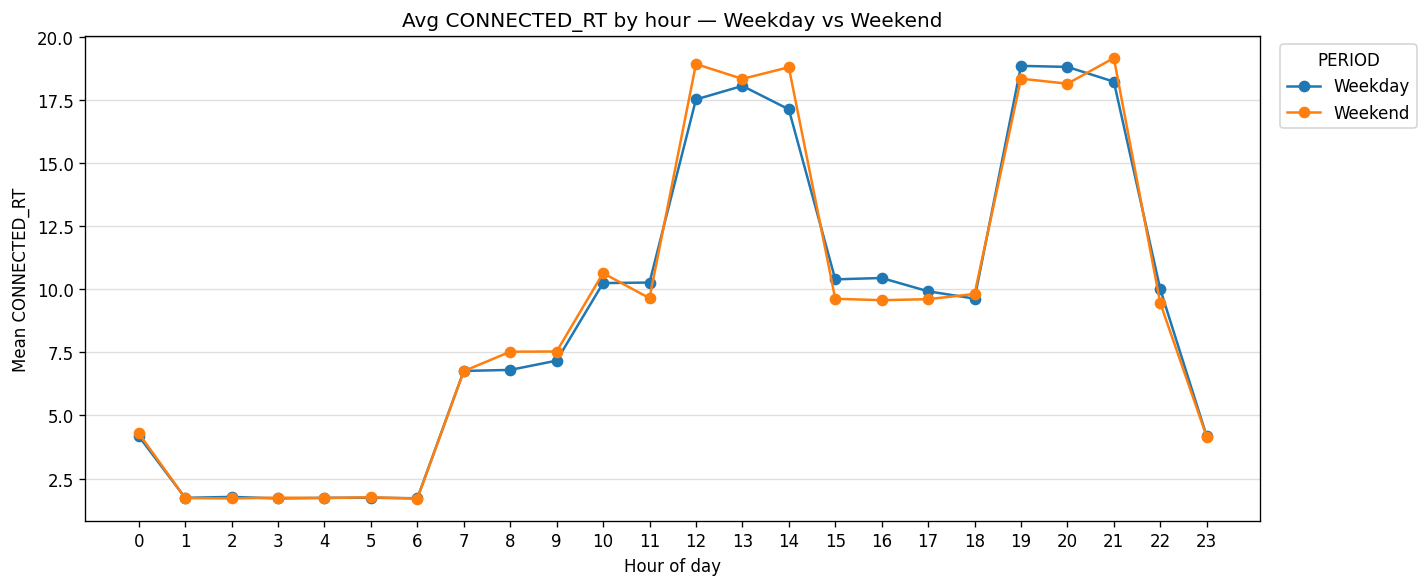

Figure saved → outputs\figures\eda_hourly_orders_weekday_vs_weekend.png


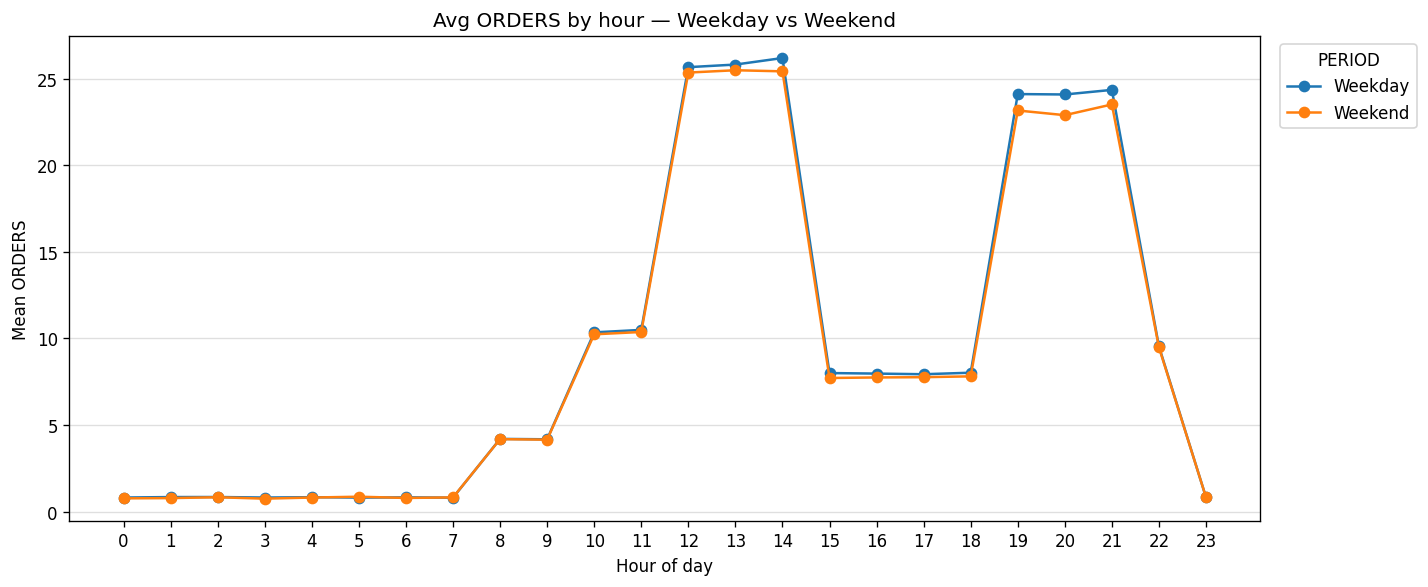

Figure saved → outputs\figures\eda_hourly_earnings_weekday_vs_weekend.png


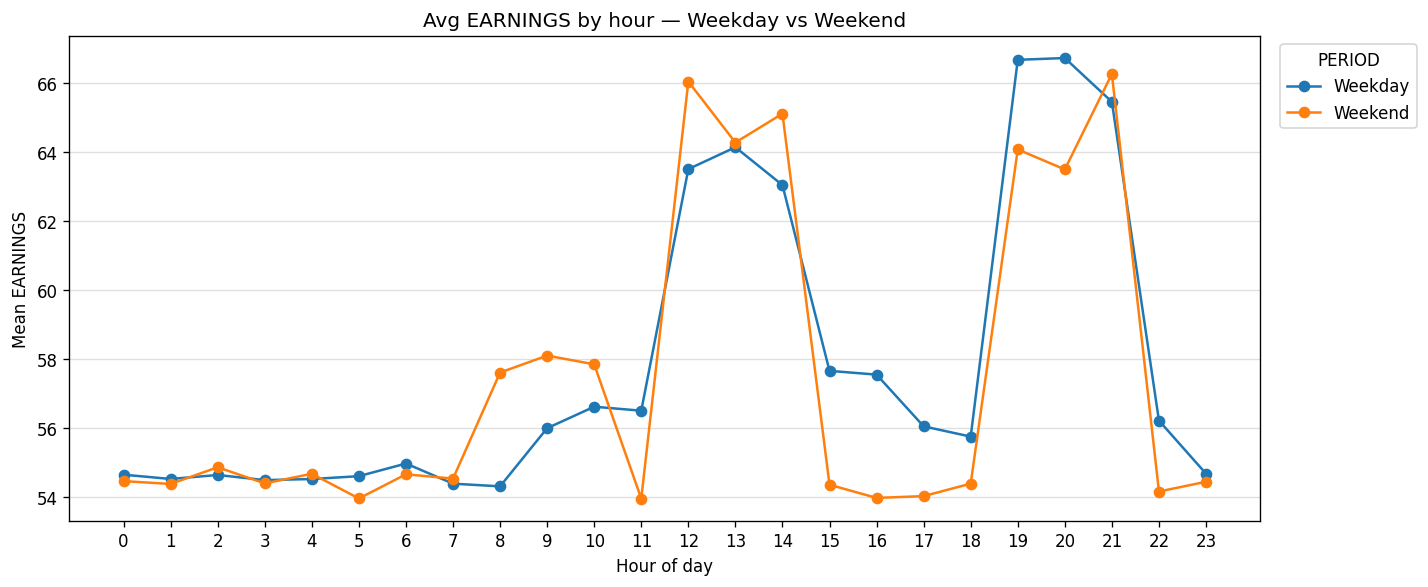

In [7]:
# Hourly profiles for all core metrics
for metric in ["CONNECTED_RT", "ORDERS", "EARNINGS", "PRECIPITATION_MM"]:
    fig = plot_hourly_profile(raw, metric, title=f"Avg {metric} by hour of day")
    save_fig(fig, f"eda_hourly_{metric.lower()}")
    plt.show()

# Weekday vs weekend hourly profiles for core operational metrics
if "IS_WEEKEND" in raw.columns:
    raw["PERIOD"] = raw["IS_WEEKEND"].map({True: "Weekend", False: "Weekday"})
    for metric in ["CONNECTED_RT", "ORDERS", "EARNINGS"]:
        fig = plot_hourly_profile(raw, metric, groupby="PERIOD",
                                  title=f"Avg {metric} by hour — Weekday vs Weekend")
        save_fig(fig, f"eda_hourly_{metric.lower()}_weekday_vs_weekend")
        plt.show()

Figure saved → outputs\figures\eda_daily_trends.png


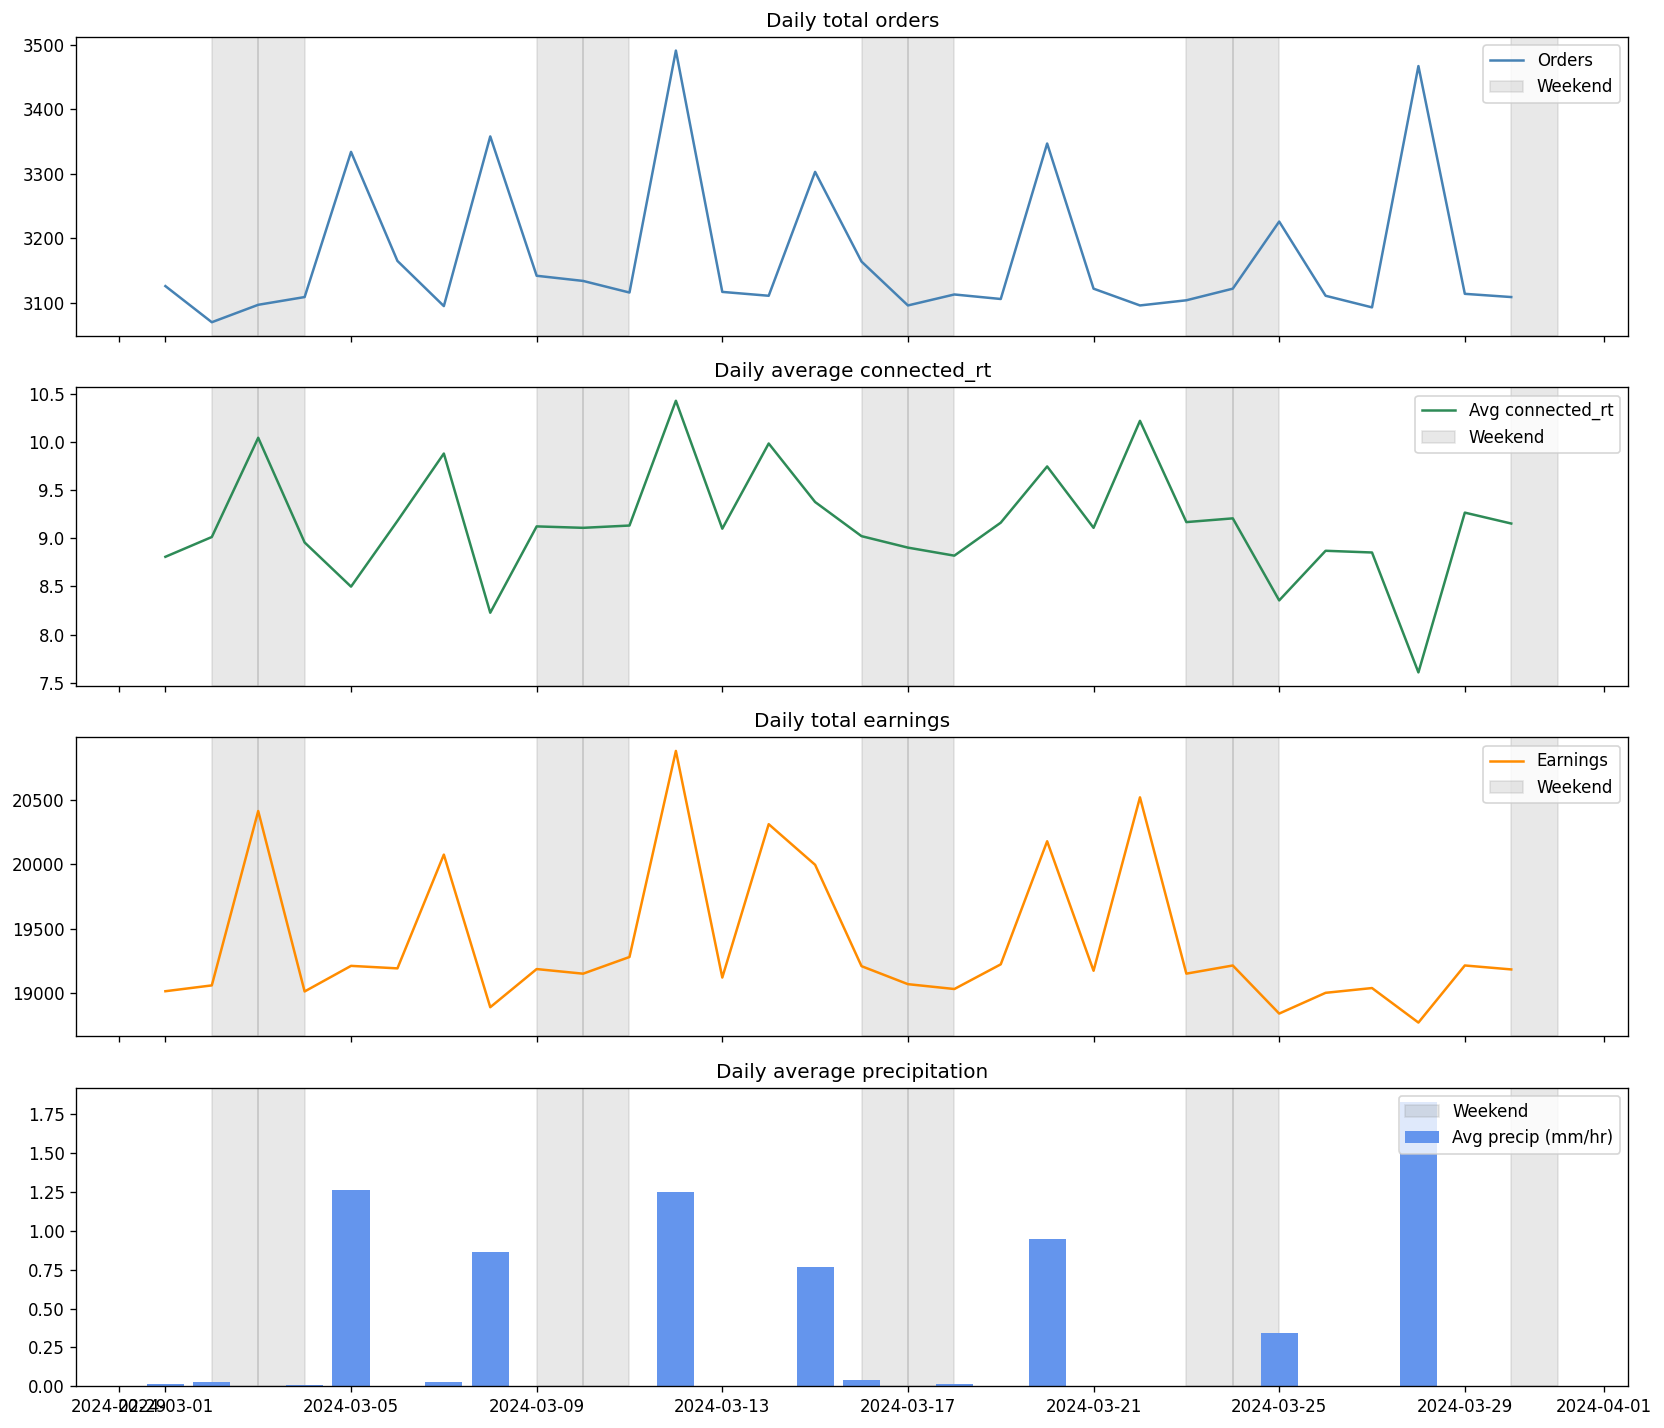

In [8]:
# Daily totals
daily = raw.groupby("DATE").agg(
    total_orders=("ORDERS", "sum"),
    total_earnings=("EARNINGS", "sum"),
    avg_connected_rt=("CONNECTED_RT", "mean"),
    avg_precipitation=("PRECIPITATION_MM", "mean"),
).reset_index()
daily["DATE"] = pd.to_datetime(daily["DATE"])
weekend_days = daily.loc[daily["DATE"].dt.dayofweek >= 5, "DATE"]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(daily["DATE"], daily["total_orders"], color="steelblue", label="Orders")
axes[0].set_title("Daily total orders")

axes[1].plot(daily["DATE"], daily["avg_connected_rt"], color="seagreen", label="Avg connected_rt")
axes[1].set_title("Daily average connected_rt")

axes[2].plot(daily["DATE"], daily["total_earnings"], color="darkorange", label="Earnings")
axes[2].set_title("Daily total earnings")

axes[3].bar(daily["DATE"], daily["avg_precipitation"], color="cornflowerblue", label="Avg precip (mm/hr)")
axes[3].set_title("Daily average precipitation")

for ax in axes:
    for i, day in enumerate(weekend_days):
        ax.axvspan(day, day + pd.Timedelta(days=1), color="gray", alpha=0.18,
                   label="Weekend" if i == 0 else None, zorder=0)
    ax.legend()

plt.tight_layout()
save_fig(fig, "eda_daily_trends")
plt.show()


---
## E. Geographic Analysis

City and zone-level summaries: demand, earnings, supply, and variability.

Zone summary (top 10 by total orders):
               ZONE  total_orders  total_earnings  avg_connected_rt  avg_orders  order_std  avg_precipitation  n_rows                                                     DESCRIPTION
             Centro         11596         41695.4         15.634722   16.105556  16.024580           0.246667     720        Downtown Monterrey – high-density commercial/residential
          San Pedro          9843         41644.3         13.212500   13.670833  13.773904           0.246667     720 Affluent municipality, high average ticket (~100m above valley)
        San Nicolás          9018         41467.2         12.000000   12.525000  12.766413           0.246667     720                                  Large residential municipality
      MTY_Guadalupe          8222         41573.4         10.909722   11.419444  11.635955           0.246667     720                         Eastern municipality, mixed residential
      Mitras Centro          8207         41545.3  

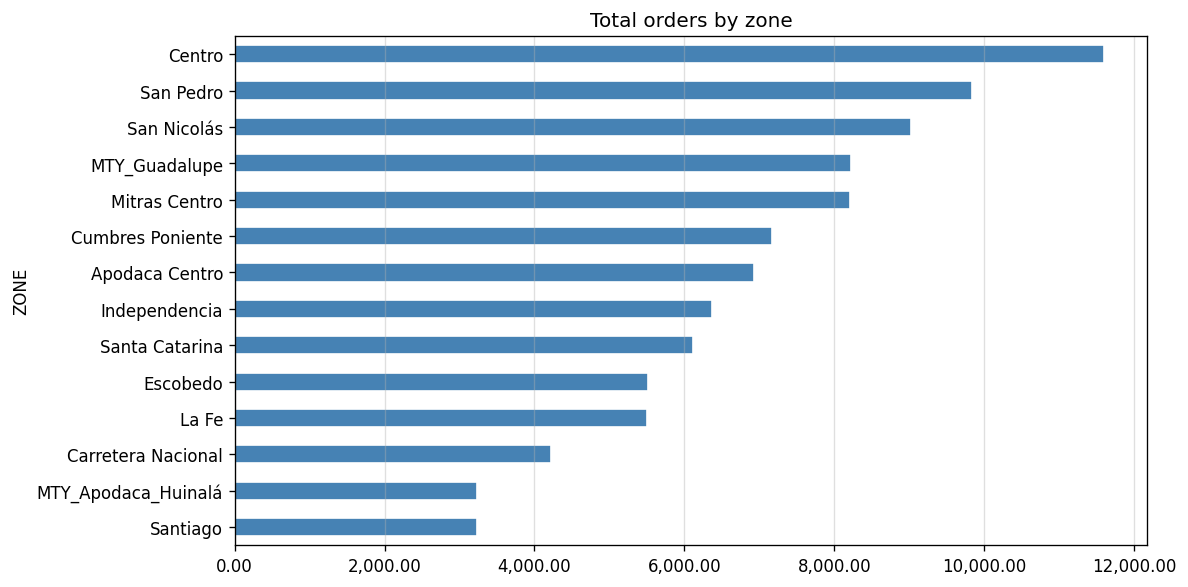

In [9]:
zone_summary = raw.groupby("ZONE").agg(
    total_orders=("ORDERS", "sum"),
    total_earnings=("EARNINGS", "sum"),
    avg_connected_rt=("CONNECTED_RT", "mean"),
    avg_orders=("ORDERS", "mean"),
    order_std=("ORDERS", "std"),
    avg_precipitation=("PRECIPITATION_MM", "mean"),
    n_rows=("ORDERS", "count"),
).reset_index().sort_values("total_orders", ascending=False)

# Enrich with ZONE_INFO descriptions if available
if "DESCRIPTION" in zone_info.columns and "ZONE" in zone_info.columns:
    zone_summary = zone_summary.merge(
        zone_info[["ZONE", "DESCRIPTION"]].drop_duplicates("ZONE"),
        on="ZONE", how="left"
    )

print("Zone summary (top 10 by total orders):")
print(zone_summary.to_string(index=False))

save_csv(zone_summary, TABLES_DIR / "eda_summary_zone.csv")

# Bar chart: top zones by total orders
fig = plot_ranked_bar(
    zone_summary.set_index("ZONE")["total_orders"],
    title="Total orders by zone",
)
save_fig(fig, "eda_zone_total_orders")
plt.show()

## E.5 Insight Support Summary

In [10]:
# # Compact summary to support the final insight bullets
# raw["PERIOD"] = raw["IS_WEEKEND"].map({True: "Weekend", False: "Weekday"})

# period_summary = raw.groupby("PERIOD")[["CONNECTED_RT", "ORDERS", "EARNINGS"]].mean().round(3)
# print("Weekday vs weekend averages:")
# print(period_summary.to_string())

# spearman_core = raw[["CONNECTED_RT", "ORDERS", "EARNINGS", "PRECIPITATION_MM"]].corr(method="spearman").round(3)
# print("\nCore Spearman correlations:")
# print(spearman_core.to_string())

# hourly_period = raw.groupby(["HOUR", "PERIOD"])[["CONNECTED_RT", "ORDERS", "EARNINGS"]].mean().unstack("PERIOD")
# weekend_lift = (
#     hourly_period.xs("Weekend", axis=1, level=1) -
#     hourly_period.xs("Weekday", axis=1, level=1)
# ).loc[[8, 9, 10, 12, 13, 14]].round(3)

# print("\nWeekend - weekday averages for highlighted hours:")
# print(weekend_lift.to_string())

---
## F. Initial Insights

- **Top demand zones:** `Centro`, `San Pedro`, `San Nicolas`, `MTY_Guadalupe`, and `Mitras Centro` lead total orders in the 30-day window.
- **Hourly patterns:** Demand peaks at `12:00-14:00` and `19:00-21:00`, with `14:00` as the single highest-order hour.
- **Weekday vs weekend:** Weekend `EARNINGS` and `CONNECTED_RT` are visibly higher around `08:00-10:00` and `12:00-14:00`, while `ORDERS` stay similar or slightly lower, so weekends appear to follow a different operating pattern rather than a simple volume increase.
- **Precipitation:** Rain is sparse (`93.9%` of rows have `0 mm/hr`), so its effect is diluted in global summaries and is better evaluated with segmented analyses by rain bucket, hour, and zone.
- **Correlations:** `CONNECTED_RT` and `ORDERS` show the strongest raw Spearman relationship (`r=0.914`), meaning busier zone-hours usually have both more riders and more demand at the same time. That does not by itself mean a healthy `RATIO`, because `ORDERS / CONNECTED_RT` can still become too high in specific hours or zones if demand grows faster than supply. `EARNINGS` is moderately related to `CONNECTED_RT` (`r=0.422`) and more weakly to `ORDERS` (`r=0.312`). `PRECIPITATION_MM` has only weak overall raw relationships with `ORDERS` (`r=0.193`) and `CONNECTED_RT` (`r=0.114`), so rain should be treated as a segmented external stressor rather than a strong global driver in the raw correlation matrix.
- **Outliers:** No rows were found with `ORDERS = 0` and unusually high `EARNINGS` (above the 90th percentile), and the IQR checks did not surface obvious data errors severe enough to drop records.

---
## G. Questions for KPI Analysis (Notebook 03)

1. **P1:** During which specific hours and zones does the `RATIO` (`ORDERS / CONNECTED_RT`) exceed `1.8`, and how often does that happen?
2. **P2:** Does precipitation systematically worsen the `RATIO`, and does that effect remain visible within the same hour of day?
3. **P3:** Which zones are most sensitive to precipitation-driven `RATIO` deterioration, and is that sensitivity explained by demand rising faster than supply?
4. **P4:** Which exact dates show overspend at the daily level, and which dates contain the largest intraday pockets of under-investment?
5. **P5:** Is the relationship between `EARNINGS` and `RATIO` weak overall but stronger under moderate/heavy rain?